

# 🔥 Постановка задачи

> На прошлом занятии мы разобрали **случайный лес** — ансамблевый метод, в котором десятки или сотни деревьев обучаются **параллельно и независимо**, а потом голосуют, чтобы получить итоговое решение. Он прост, надёжен и мощный.
>
> Но... у случайного леса есть своя философия: *«давай построим много деревьев и усредним их ошибки»*.
>
> Сегодня мы разберём **альтернативную философию**, которая звучит так:
>
> **«Давайте не строить кучу деревьев сразу, а будем строить их **по очереди**, и каждое следующее дерево будет исправлять ошибки предыдущих».**
>
> Это подход называется **бустинг** (от англ. *to boost* — усиливать).
> Он не про усреднение, как случайный лес, а про **поэтапное приближение к истине**, как если бы мы постоянно подкручивали предсказание, чтобы оно стало чуть точнее.

---

## ❓Зачем вообще изобретали бустинг?

1. **Некоторые алгоритмы (например, деревья)** слабы сами по себе — глубина 1–3, простые, быстро обучаются.
2. Но если каждый раз строить модель, которая **улучшает предсказания предыдущих**, можно получить **очень сильную финальную модель**.
3. Это **не бэггинг**, а **умная адаптивная комбинация слабых моделей** — бустинг.

---

## 🧪 Исторические предпосылки:

* Начиналось с **вопроса в теории обучения**:

  > *Если у нас есть слабый алгоритм, который чуть лучше случайного угадывания, можно ли из него сделать сильный?*
* Ответ: **да, если обучать их последовательно**, исправляя ошибки.

---

## 📦 Какие бывают бустинги:

| Вид                              | Идея                                                                                                  | Пример                      |
| -------------------------------- | ----------------------------------------------------------------------------------------------------- | --------------------------- |
| **AdaBoost**                     | Каждое новое дерево фокусируется на тех примерах, где ошиблись предыдущие (через веса объектов)       | Классический бустинг        |
| **Gradient Boosting**            | Каждое дерево приближает **градиент функции потерь** — направление, куда нужно подвинуть предсказание | XGBoost, LightGBM, CatBoost |
| **LogitBoost, BrownBoost, etc.** | Разные варианты с разными функциями потерь и математическими основами                                 | Специализированные          |

> Сегодня мы сосредоточимся на двух ключевых идеях:
>
> * **AdaBoost** — исторически первый, простой, концептуально важный
> * **Градиентный бустинг** — универсальный, мощный, лежит в основе всех современных библиотек

---

## 🧨 Почему это важно

* Бустинг — это **одна из самых мощных идей в ML**.
* Почти все победители Kaggle используют **градиентный бустинг**.
* Это — **мозг большинства "черных ящиков"** в индустрии: скоринг, рекомендательные системы, кредитные модели.

---

## 🎯 Что будет на этом занятии

* Мы разберём:

  ✅ **Как бустинг работает шаг за шагом**

  ✅ **Как деревья "учатся на ошибках"**

  ✅ **Чем отличается AdaBoost от Gradient Boosting**

  ✅ **Почему градиенты, веса, экспоненты и всё остальное тут не просто так**

И да, бустинг выглядит как «хитрая х__ня» — потому что это действительно **очень умная конструкция**. Но за ней стоит весьма злая математика и огромный исторический пласт развития машинного обучения...

ПРЕДУПРЕЖДЕНИЕ - вы не найдете "книжку с хорошим объяснением" этого материала в ключе "объясни мне на пальцах" ибо понять это в деталях - это быть уже сильно искушенным в математике, Байесовых процессах и в машинном обучении в целом! Изучать данный материал - это читать литературу которая написана для профессионалов и переложить этот материал для неподготовленного читателя практически невозможно... НО!! Мы поговорим об этом потому, что каждый из вас обязательно достигнет такого уровня погружения в профессию, когда вам самим захочется в этом всем разобраться! Вы будете снова и снова возвращаться к этму материалу. А пока это будет "Экскурсией" которая покажет вам перспективы!) Не пугайтесь!





# 🔥 **AdaBoost с деревьями

---

## 🧩 **Входные данные:**

* Обучающая выборка:

  $$
  \mathscr{D} = \{(x_1, y_1), \ldots, (x_N, y_N)\}, \quad y_i \in \{-1, +1\}
  $$
* Число итераций (число слабых деревьев): $M$

---

## ⚙️ **Шаг 0: Инициализация весов объектов**

* Каждому объекту $x_i$ присваиваем вес:

  $$
  w_i^{(1)} = \frac{1}{N}
  $$

* Интерпретация: на первом шаге все примеры считаются одинаково важными.

---

## 🔁 **Для $m = 1, 2, \ldots, M$:**

---

### ✅ **Шаг 1. Обучаем слабое дерево $h_m(x)$ на всей выборке с весами $w_i^{(m)}$**

#### 🧮 **Как веса входят в построение дерева?**

##### Разделение по Джини (взвешенный):

Обычно критерий Джини:

$$
G(S) = 1 - \sum_{k} p_k^2
$$

Во взвешенном виде:

$$
G(S) = 1 - \sum_{k} \left( \frac{\sum_{x_i \in S_k} w_i}{\sum_{x_i \in S} w_i} \right)^2
$$

* $S$ — множество объектов в узле.
* $S_k$ — объекты класса $k$.
* $\sum w_i$ — вес всех объектов.
* Интерпретация: мы имеем дело с эмпирической вероятностью классов (с учётом весов)

##### Альтернатива: Взвешенная энтропия (Information Gain)

Обычная энтропия:

$$
H(S) = - \sum_k p_k \log p_k
$$

Во взвешенном виде:

$$
H(S) = - \sum_k \left( \frac{\sum_{x_i \in S_k} w_i}{\sum_{x_i \in S} w_i} \right) \cdot \log \left( \frac{\sum_{x_i \in S_k} w_i}{\sum_{x_i \in S} w_i} \right)
$$

**Информационный выигрыш** (выбор наилучшего сплита):

$$
Q = H(S_{\text{parent}}) - \left( \frac{\sum_{i \in S_L} w_i}{\sum_{i \in S} w_i} H(S_L) + \frac{\sum_{i \in S_R} w_i}{\sum_{i \in S} w_i} H(S_R) \right)
$$

* Интерпретация: выбирается тот сплит, который **наиболее сильно уменьшает взвешенную энтропию**, т.е. **лучше разделяет важные объекты**.

---

### ✅ **Шаг 2. Взвешенная ошибка классификатора:**

$$
\varepsilon_m = \sum_{i=1}^N w_i^{(m)} \cdot \mathbb{I}\left[ h_m(x_i) \ne y_i \right]
$$

* $\mathbb{I}[\cdot]$ — индикатор ошибки.
* Ошибки по более важным объектам «стоят» дороже.

---

### ✅ **Шаг 3. Вес (уверенность) классификатора:**

$$
\alpha_m = \frac{1}{2} \ln\left(\frac{1 - \varepsilon_m}{\varepsilon_m}\right)
$$

* Интуиция:

  * Если $\varepsilon_m = 0.5$: $\alpha_m = 0$ → модель бесполезна.
  * Если $\varepsilon_m < 0.5$: $\alpha_m > 0$ → даём модели вес.
  * Чем меньше ошибка, тем больше влияние модели в ансамбле.

---


### ✅ **Шаг 4. Обновление весов объектов:**

$$
w_i^{(m+1)} = \frac{w_i^{(m)} \cdot \exp\left(-\alpha_m y_i h_m(x_i)\right)}{Z_m}
$$

* $Z_m$ — нормализующий коэффициент:

  $$
  Z_m = \sum_{i=1}^N w_i^{(m)} \cdot \exp\left(-\alpha_m y_i h_m(x_i)\right)
  $$

#### 🔍 Интерпретация экспоненты:

* Если $y_i = h_m(x_i)$ (правильно): $\exp(-\alpha_m) < 1$ → вес уменьшается.
* Если ошибка: $\exp(+\alpha_m) > 1$ → вес увеличивается.
* **Чем сильнее классификатор (больше $\alpha$), тем сильнее «наказывается» ошибка.**

---

## 🧮 Финальное предсказание:

$$
H(x) = \text{sign}\left( \sum_{m=1}^M \alpha_m h_m(x) \right)
$$

* Взвешенное голосование всех деревьев.
* Деревья, которые были более точны (низкая ошибка), получают большее влияние.

---


## 🔍 Почему логарифм? Почему экспонента?

### 📚 Истоки: **Минимизация экспоненциальной функции потерь**

AdaBoost минимизирует:

$$
\mathscr{L} = \sum_{i=1}^N \exp\left(-y_i F(x_i)\right), \quad \text{где } F(x) = \sum_{m=1}^M \alpha_m h_m(x)
$$

* Это **upper bound** (оценка сверху) для 0-1 loss:

  $$
  \mathbb{I}[y_i \ne \text{sign}(F(x_i))] \le \exp(-y_i F(x_i))
  $$

* Именно отсюда взяты формулы $\exp(-\alpha_m y_i h_m(x_i))$, и логарифмическая формула для $\alpha_m$ — из минимизации этой экспоненциальной функции потерь по $\alpha$.

> 👉 Это можно рассматривать как **максимизацию правдоподобия в логистической модели** в байесовском смысле.

---



# 🎯 **Градиентный бустинг**

Мы хотим построить модель $F(x)$, которая **минимизирует сумму ошибок на обучении**:

$$
\mathscr{L}(F) = \sum_{i=1}^N \mathscr{L}(y_i, F(x_i))
$$

где:

* $\mathscr{L}(y, \hat{y})$ — функция потерь (например, MSE, логистическая и т.д.),
* $F(x)$ — ансамбль деревьев.

---

# 🔍 Что такое **$F(x)$**?

Это просто **функция предсказания** — не конкретное дерево, а сумма всех деревьев:

$$
F(x) = \sum_{m=0}^M f_m(x)
$$

где:

* $f_m(x)$ — предсказание очередного дерева,
* $F_0(x)$ — начальное приближение (об этом ниже),
* далее мы добавляем корректировки: $f_1, f_2, \ldots$ к ошибкам предыдущих.

---

# 🔵 Шаг 0: Начальное приближение $F_0(x)$

В градиентном бустинге **начальное приближение** — это такая константа, которая минимизирует функцию потерь на всех объектах **при фиксированном выходе** $F(x_i) \equiv c$.

### 🔍 Примеры:

* Для **MSE**:

  $$
  F_0(x) = \arg\min_c \sum_i (y_i - c)^2 = \bar{y}
  $$

  → это среднее по целевым значениям.

* Для **логистической потери** (классификация):

  $$
  \mathscr{L}(y, F(x)) = \log(1 + e^{-y F(x)})
  \Rightarrow F_0(x) = \frac{1}{2} \ln\left( \frac{p}{1 - p} \right), \quad p = \frac{1}{N} \sum_i \mathbb{I}(y_i = 1)
  $$

Это просто стартовая точка. С неё мы **пошагово двигаемся к минимуму ошибки**, добавляя деревья.

---

# 🔁 Общая идея шагов:

На каждом шаге мы приближаем решение задачи:

$$
F^* = \arg\min_F \sum_i \mathscr{L}(y_i, F(x_i))
$$

Сделать это напрямую невозможно (деревья нельзя «дифференцировать»), поэтому мы делаем **градиентный спуск в функциональном пространстве**:

---

# 🔺 Градиент в функциональном пространстве

На шаге $m$ мы имеем текущую модель:

$$
F_{m-1}(x) = f_0(x) + f_1(x) + \ldots + f_{m-1}(x)
$$

И мы хотим построить новое дерево $f_m(x)$, которое будет двигаться в сторону **наискорейшего убывания** ошибки.

---

## ✅ Как это делается:

### 1. **Считаем антиградиент функции потерь по каждому объекту**

На каждом объекте $x_i$, считаем:

$$
r_i^{(m)} = -\left. \frac{\partial \mathscr{L}(y_i, F(x_i))}{\partial F(x_i)} \right|_{F(x_i) = F_{m-1}(x_i)}
$$

* Это **аналог антиградиента по параметру $F(x)$**.
* Это вектор: по одному числу на каждый объект.
* Мы **ищем, насколько нужно скорректировать предсказание на $x_i$, чтобы уменьшить ошибку**.

> ❗ Мы не берём производную по дереву! Мы берём производную по **значению функции $F(x)$**, которое выдает ансамбль. Это и есть объект оптимизации.

---

### 2. **Обучаем дерево $f_m(x)$ на выборке $(x_i, r_i^{(m)})$**

Это важнейший шаг!

* Мы трактуем $r_i^{(m)}$ как **целевую переменную**,
* И обучаем **регрессионное дерево**, которое аппроксимирует зависимость:

  $$
  x_i \mapsto r_i^{(m)}
  $$

> То есть дерево учится **предсказывать, как скорректировать предсказание модели, чтобы уменьшить ошибку**.

---

### 3. **Определяем шаг по направлению дерева:**

Теперь мы хотим подобрать **оптимальный множитель $\gamma_m$**, чтобы минимизировать ошибку:

$$
\gamma_m = \arg\min_\gamma \sum_{i=1}^N \mathscr{L}(y_i, F_{m-1}(x_i) + \gamma f_m(x_i))
$$

> Это аналог **поиска длины шага в градиентном спуске**.

* Для MSE это просто: $\gamma_m = 1$
* Для логистической — можно найти приближённо (или делать фиксированный шаг)

---

### 4. **Обновляем модель:**

$$
F_m(x) = F_{m-1}(x) + \eta \cdot \gamma_m f_m(x)
$$

* $\eta \in (0, 1]$ — темп обучения (learning rate).
* **Теперь предсказание модели стало ближе к правильному значению.**

---

# 🎯 Пример: MSE

### Пусть:

$$
\mathscr{L}(y_i, F(x_i)) = \frac{1}{2}(y_i - F(x_i))^2
$$

### Тогда:

$$
\frac{\partial \mathscr{L}}{\partial F(x_i)} = F(x_i) - y_i \Rightarrow
r_i^{(m)} = y_i - F_{m-1}(x_i)
$$

* То есть **остаток** между истинным и предсказанным значением.
* Мы обучаем дерево на этих остатках.
* Добавляем его к ансамблю:

  $$
  F_m(x) = F_{m-1}(x) + \eta f_m(x)
  $$

Это буквально пошаговое приближение по **градиенту** ошибки.

---

# 📌 Итого: вся цепочка

1. **Стартуем с константы $F_0$ — минимум по всем $y_i$**.
2. **На каждом шаге:**

   * Считаем частные производные потерь по $F(x_i)$,
   * Строим дерево, предсказывающее эти значения,
   * Подбираем шаг (коэффициент),
   * Обновляем предсказания $F(x) \leftarrow F(x) + \eta \gamma_m f_m(x)$.

---

# ⚠️ Почему берём производные по $F(x)$?

Потому что **именно $F(x)$** — это то, что мы строим. Это и есть объект оптимизации!

* Мы **не оптимизируем веса деревьев напрямую**, а строим функцию $F(x)$, которая является суммой деревьев.
* Производные по $F(x)$ — это то же самое, что градиент функции потерь по значениям предсказаний.
* Мы ищем такие функции $f_m(x)$, которые **направлены вдоль антиградиента**.


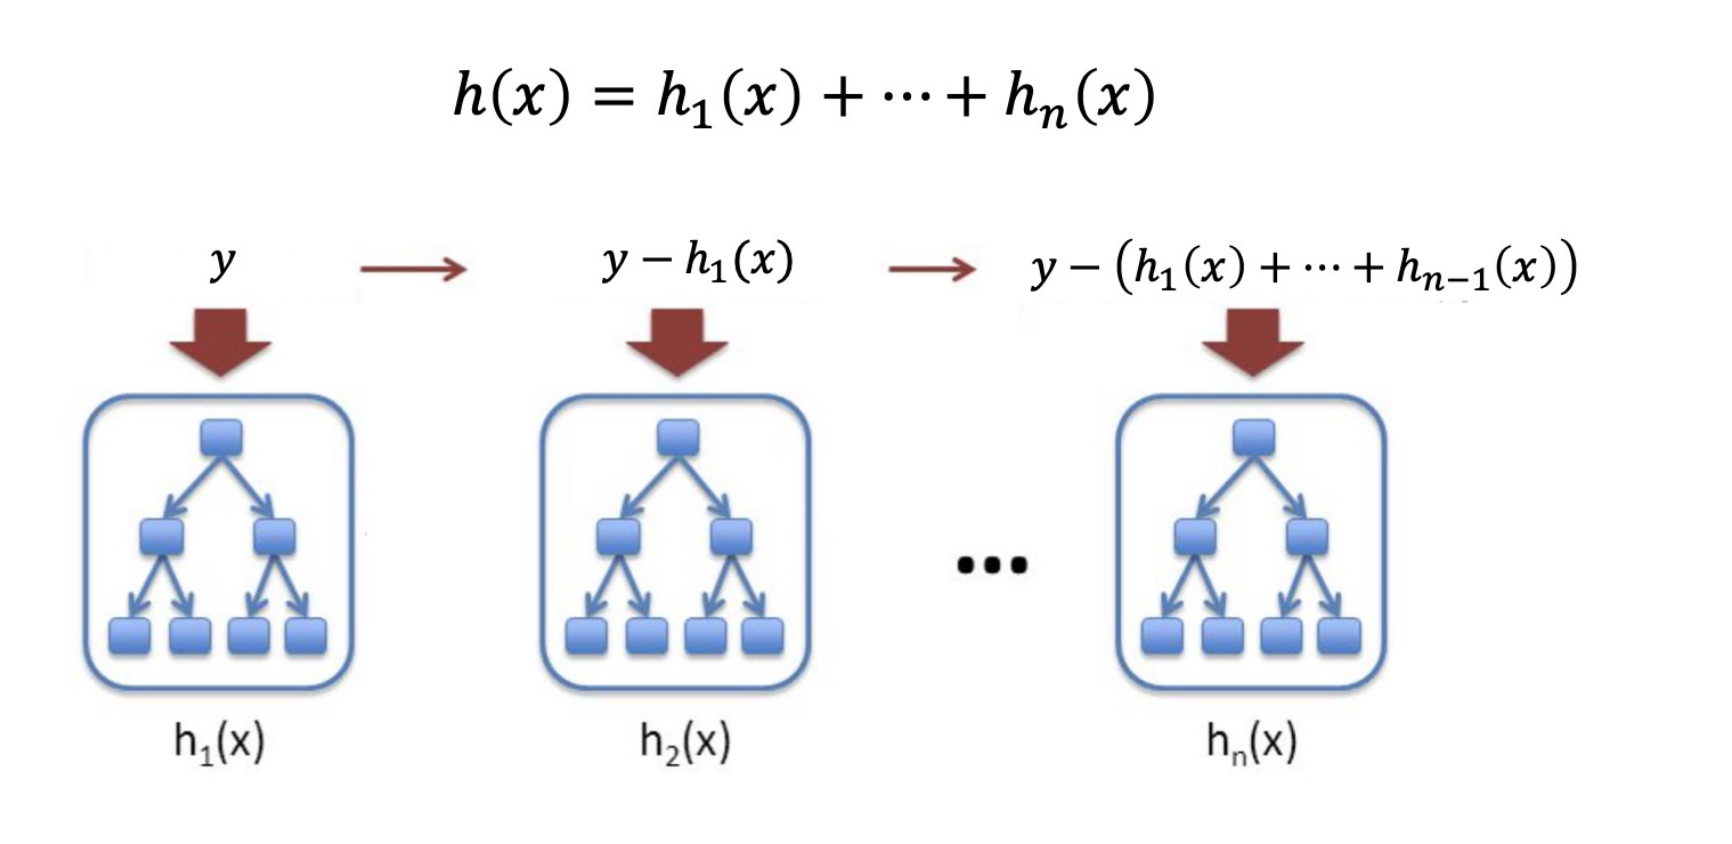

# Part 1. Bagging and gradient boosting.

Сравним, как ведут себя бустинг и бэггинг c ростом числа базовых алгоритмов.

В случае бэггинга все базовые алгоритмы настраиваются на различные выборки из одного и того же распределения на $\mathbb{X} \times \mathbb{Y}$. При этом некоторые из них могут оказаться переобученными, однако усреднение позволяет ослабить этот эффект (объясняется тем, что для некоррелированных алгоритмов разброс композиции оказывается в  $N$ раз меньше разброса отдельных алгоритмов, т.е. много деревьев с меньшей вероятностью настроятся на некоторый нетипичный объект по сравнению с одним деревом). Если $N$ достаточно велико, то последующие добавления новых алгоритмов уже не позволят.

В случае же бустинга каждый алгоритм настраивается на ошибки всех предыдущих, это позволяет на каждом шаге настраиваться на исходное распределение все точнее и точнее. Однако при достаточно большом $N$ это является источником переобучения, поскольку последующие добавления новых алгоритмов будут продолжать настраиваться на обучающую выборку, уменьшая ошибку на ней, при этом уменьшая обобщающую способность итоговой композиции.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

Firstly, let's generate a synthetic dataset.

Firstly, let's take bagging of decision trees algorithm.

Here, the ensemble size is being gradually increased.
Let's look at how the prediction depends on the size.

In [ ]:
#@title plot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from ipywidgets import interact, IntSlider
from IPython.display import display

X_train = np.linspace(0, 1, 100)
X_test = np.linspace(0, 1, 1000)

@np.vectorize
def target(x):
    return x > 0.5

Y_train = target(X_train) + np.random.randn(*X_train.shape) * 0.1

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
Y_train = Y_train.ravel()

def plot_bagging(n_estimators):
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(max_depth=2),
        n_estimators=n_estimators
    )
    model.fit(X_train, Y_train)
    preds = model.predict(X_test)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_train, Y_train, s=60, alpha=0.6, label="Train", color='Grey', edgecolor='black')
    plt.plot(X_test, preds, color='green', linewidth=3, label="Prediction")
    plt.title(f"Bagging with {n_estimators} trees")
    plt.ylim([-0.5, 1.5])
    plt.xlim([0, 1])
    plt.grid(True)
    plt.legend()
    plt.show()


interact(plot_bagging, n_estimators=IntSlider(min=1, max=500, step=1, value=10, description="n_trees"))


Можно заметить, что с некоторого момента итоговая функция перестает меняться с ростом количества деревьев.

Теперь проделаем то же самое для градинентного бустинга.

In [ ]:
#@title plot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from ipywidgets import interact, IntSlider

X_train = np.linspace(0, 1, 100)
X_test = np.linspace(0, 1, 1000)

@np.vectorize
def target(x):
    return x > 0.5

Y_train = target(X_train) + np.random.randn(*X_train.shape) * 0.1

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
Y_train = Y_train.ravel()


def plot_gb(n_estimators):
    model = GradientBoostingRegressor(
        n_estimators=n_estimators,
        max_depth=1,
        learning_rate=1,
        warm_start=False
    )
    model.fit(X_train, Y_train)
    preds = model.predict(X_test)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_train, Y_train, s=60, alpha=0.6, label="Train", color='Grey', edgecolor='black')
    plt.plot(X_test, preds, color='blue', linewidth=3, label="Prediction")
    plt.title(f"Gradient Boosting ({n_estimators} trees)")
    plt.ylim([-0.5, 1.5])
    plt.xlim([0, 1])
    plt.grid(True)
    plt.legend()
    plt.show()

interact(plot_gb, n_estimators=IntSlider(min=1, max=1000, step=1, value=10, description="n_trees"))


Градиентный бустинг довольно быстро построил истинную зависимость, после чего начал настраиваться уже на конкретные объекты обучающей выборки, из-за чего сильно переобучился.


Бороться с этой проблемой можно с помощью выбора очень простого базового алгоритма или
же искусственным снижением веса новых алгоритмов при помощи шага $\eta$:
$$a_N(x) = \sum_{n=0}^N \eta \gamma_N b_n(x).$$

Такая поправка замедляет обучение по сравнению с бэггингом, но зато позволяет получить менее переобученный алгоритм. Тем не менее, важно понимать, что переобучение всё равно будет иметь место при обучении сколь угодно большого количества базовых алгоритмов для фиксированного $\eta$.

In [ ]:
reg = GradientBoostingRegressor(max_depth=1, learning_rate=0.1, warm_start=True)
plt.figure(figsize=(20, 30))
sizes = [1, 2, 5, 20, 100, 500, 1000, 2000]
for i, s in enumerate(sizes):
    reg.n_estimators = s
    reg.fit(X_train.reshape(-1, 1), Y_train)
    plt.subplot(4, 2, i+1)
    plt.xlim([0, 1])
    plt.scatter(X_train, Y_train, s=30)
    plt.plot(X_test, reg.predict(X_test.reshape(-1, 1)), c='green', linewidth=4)
    plt.title('{} trees'.format(s))

Теперь проверим описанный выше эффект на реальных данных.

In [ ]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

ds = datasets.load_diabetes()
X = ds.data
Y = ds.target
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.5, test_size=0.5)

MAX_ESTIMATORS = 300

gbclf = BaggingRegressor(warm_start=True)
err_train_bag = []
err_test_bag = []
for i in range(1, MAX_ESTIMATORS+1):
    gbclf.n_estimators = i
    gbclf.fit(X_train, Y_train)
    err_train_bag.append(1 - gbclf.score(X_train, Y_train))
    err_test_bag.append(1 - gbclf.score(X_test, Y_test))

gbclf = GradientBoostingRegressor(warm_start=True, max_depth=2, learning_rate=0.1)
err_train_gb = []
err_test_gb = []
for i in range(1, MAX_ESTIMATORS+1):
    gbclf.n_estimators = i
    gbclf.fit(X_train, Y_train)
    err_train_gb.append(1 - gbclf.score(X_train, Y_train))
    err_test_gb.append(1 - gbclf.score(X_test, Y_test))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(err_train_gb, label='GB')
plt.plot(err_train_bag, label='Bagging')
plt.legend()
plt.title('Train')
plt.subplot(1, 2, 2)
plt.plot(err_test_gb, label='GB')
plt.plot(err_test_bag, label='Bagging')
plt.legend()
plt.title('Test')
plt.gcf().set_size_inches(15,7)

In [ ]:
X_train.shape

# Part 2. Multilabel classification with Decision Trees, Random Forests, and Gradient Boosting.

In the second part of our practice session, we will apply each method to the classification task and do optimal model selection.

In [ ]:
from sklearn.datasets import load_digits

data = load_digits()
X = data.data
y = data.target

We're going to use the digits dataset. This is a task of recognizing hand-written digits - a multilabel classification into 10 classes.

In [ ]:
np.unique(y)

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(6, 6))
fig.suptitle("Training data examples")

for i in range(9):
    img = X[i].reshape(8, 8)
    axs[i // 3, i % 3].imshow(img)
    axs[i // 3, i % 3].set_title("Class label: %s" % y[i])

In [ ]:
X.shape

Firstly, split the dataset in order to be able to validate your model.

**Hint**: use sklearn's `ShuffleSplit` or `train_test_split`.

In [ ]:
# Split the dataset. Use any method you prefer

#### Decision trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create and fit decision tree with the default parameters
# Evaluate it on the validation set. Use accuracy

#### Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create RandomForestClassifier with the default parameters
# Fit and evaluate

In [ ]:
# Now let's see how the quality depends on the number of models in the ensemble
# For each value in [5, 10, 100, 500, 1000] create a random forest with the corresponding size, fit a model and evaluate
# How does the quality change? What number is sufficient?
# Please write you conslusions

#### Gradient boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Create GradientBoostingClassifier with the default parameters
# Fit and evaluate. Compare its quality to random forest

In [ ]:
# Now let's see how the quality depends on the number of models in the ensemble
# For each value in [5, 10, 100, 500, 1000] train a gradient boosting with the corresponding size
# How does the quality change? What number is sufficient?
# Please write you conslusions

## XGBoost

[Features](https://arxiv.org/pdf/1603.02754.pdf):

1. Parallelization, optimization and sparse/missing data support

2. Base algorithm approximates the direction, computred using second-order loss function derivatives.

3. Regularized Learning Objective: penalty for leaf number and coefficient norms are added.

4. Weighted Quantile Sketch algorithm proposed to select tree node split points.


##### Installation

http://xgboost.readthedocs.io/en/latest/build.html


In [ ]:
import xgboost as xgb


In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
model = CatBoostRegressor()

# ИТОГИ


## 📌 1. **Что такое градиенты в градиентном бустинге?**

На каждом шаге градиентного бустинга, для каждого объекта $x_i$ считается:

$$
g_i^{(m)} = - \left. \frac{\partial \mathscr{L}(y_i, F(x_i))}{\partial F(x_i)} \right|_{F = F_{m-1}}
$$

* Эти значения называются **псевдо-остатками**.
* Они отражают, **насколько сильно текущее предсказание отклоняется от желаемого**, с учётом формы функции потерь.

---

## 🔎 2. **Зачем сохранять или анализировать градиенты?**

### ✅ Интерпретация обучения:

* По величине и знаку градиента $g_i^{(m)}$ можно судить:

  * Насколько **ошиблась** модель на шаге $m$,
  * В каком **направлении нужно двигаться**, чтобы улучшить результат.

* Объекты с **большими по модулю градиентами**:

  * регулярно "страдают" от ошибок,
  * могут быть **шумными**, **аномальными**, **сложно классифицируемыми**,
  * или просто **подвержены переобучению**.

---

### ✅ Интерпретация по итогу всех шагов:

* Сохранив матрицу $G \in \mathbb{R}^{N \times M}$, где $G_{i,m} = g_i^{(m)}$, можно:

  1. **Анализировать траекторию обучения каждого объекта**.
  2. Вычислять **стабильность предсказаний**:

     * Большие колебания $g_i^{(m)}$ → локально высокая вариативность.
  3. Строить **диагностику bias/variance** для каждого объекта.

---

## 📉 3. **Пример: эмпирическая дисперсия ошибки на объекте**

Для объекта $x_i$, ты можешь:

* записать вектор предсказаний $F^{(m)}(x_i)$ по шагам,
* рассчитать:

$$
\text{Var}_i = \frac{1}{M} \sum_{m=1}^M \left( F^{(m)}(x_i) - \bar{F}(x_i) \right)^2
$$

* или же использовать градиенты:

$$
\text{GradientSpread}_i = \frac{1}{M} \sum_{m=1}^M (g_i^{(m)})^2
$$

→ Объекты с высокой суммой квадратов градиентов — те, на которых модель **много ошибалась и пыталась исправляться**.

---

## 📍 4. **А что можно сделать с этой информацией?**

* 📌 **Отладка модели**: найти, кто систематически труден для модели — возможно, ошибки разметки, шум, выбросы.
* 🔬 **Интерпретация результата**: показать, почему объект был классифицирован именно так — не через фичи, а через процесс обучения.
* 📊 **Оценка локального доверия**: если на объекте градиенты долго колебались — модель "не уверена", можно понизить доверие.
* 🧩 **Active learning**: использовать объекты с высокими градиентами как кандидаты для уточнения или дополнительной аннотации.

---

## 🧰 5. **Как извлекать это на практике?**

* В **CatBoost**, **XGBoost**, **LightGBM**:

  * часто можно "включить" сохранение градиентов или шагов предсказания.
  * или сделать пост-фактум реконструкцию по сохранённым деревьям.

* В XGBoost:

  * можно сохранить значения `prediction_cache` и `gradients`.
  * Также, можно **перезапустить бустинг на каждой итерации вручную**, чтобы логировать $g_i^{(m)}$.

---

## ✅ Вывод

> **Да**, градиенты в градиентном бустинге — это не просто служебные величины.
> Они содержат **ценнейшую информацию об обучении модели**, которую можно использовать для:
>
> * **диагностики сложных объектов**,
> * **оценки устойчивости**,
> * **объяснения поведения**,
> * **и даже интроспекции алгоритма**.




In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [ ]:
!pip install plotly

In [ ]:
!pip install catboost
!wget  -O 'train_sem2.csv' -q 'https://www.dropbox.com/scl/fi/65u0zpc8dweb9rx1tlzol/train_sem2.csv?rlkey=5vi4mt47fs6magpldgj5wp2u9&dl=0'
data = pd.read_csv("train_sem2.csv")


In [ ]:
data.head()

In [ ]:
from catboost import CatBoostRegressor, Pool

y = data["SalePrice"]
X = data.drop(columns=["SalePrice", "Id"])

cat_features = X.select_dtypes(include="object").columns.tolist()

X[cat_features] = X[cat_features].fillna('None')


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)


model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    loss_function='RMSE',
    verbose=100,
    random_seed=42
)

model.fit(train_pool, plot=True, eval_set=(X_test, y_test))



In [ ]:
y_pred = model.predict(test_pool)

In [ ]:
mean_absolute_percentage_error(y_test, y_pred)

In [ ]:
y_train_predict = model.predict(train_pool)

In [ ]:
sns.scatterplot(x=y_train, y=y_train_predict-y_train, color='grey', edgecolor='black', alpha=.8)

In [ ]:
plt.subplots(figsize=(6, 12))
sns.barplot(x=model.feature_importances_, y=model.feature_names_)